In [1]:
# Step 0: Environment Setup & Libraries

import os
import warnings
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
 accuracy_score, precision_score, recall_score, f1_score,
 confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
)
# Global Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Liberaries Imported Sucessfully")

Liberaries Imported Sucessfully


In [3]:
# =============================================
# Step 1: Download & Load Spam Dataset
# =============================================
print("STEP 1: DOWNLOADING SPAM DATASET FROM SOURCE")
print("=" * 45)

url_direct = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

try:
    # Download dataset
    urllib.request.urlretrieve(url_direct,"sms_data.tsv")
    print("Dataset downloaded successfully from GitHub!")
    # Load dataset
    df = pd.read_csv("sms_data.tsv",sep="\t",header=None,names=["label", "message"])
except Exception as e:
    print("Primary source failed.")
    print("Loading backup dataset...")
    # Small backup spam dataset
    data = {
        "label": ["ham","ham","spam","spam","ham","spam"],
        "message": ["Hey, are you coming to class today?",
                    "Can you send me the project file?",
                    "Congratulations! You won a free lottery prize.",
                    "Win money now! Click this link.",
                    "Let's meet tomorrow morning.",
                    "You have been selected for a free gift." ]}
    df = pd.DataFrame(data)

# =============================================
# Dataset Exploration
# =============================================

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Messages:")
print(df.head())

print("\nClass Distribution:")
print(df["label"].value_counts())

# Percentage of spam messages
spam_percentage = (df["label"].value_counts(normalize=True).get("spam", 0)* 100)
print(f"\nSpam Percentage: {spam_percentage:.2f}%")

STEP 1: DOWNLOADING SPAM DATASET FROM SOURCE
Dataset downloaded successfully from GitHub!

Dataset Shape:
(5572, 2)

First 5 Messages:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam Percentage: 13.41%


STEP 2: VISUALIZING SPAM VS HAM PATTERNS


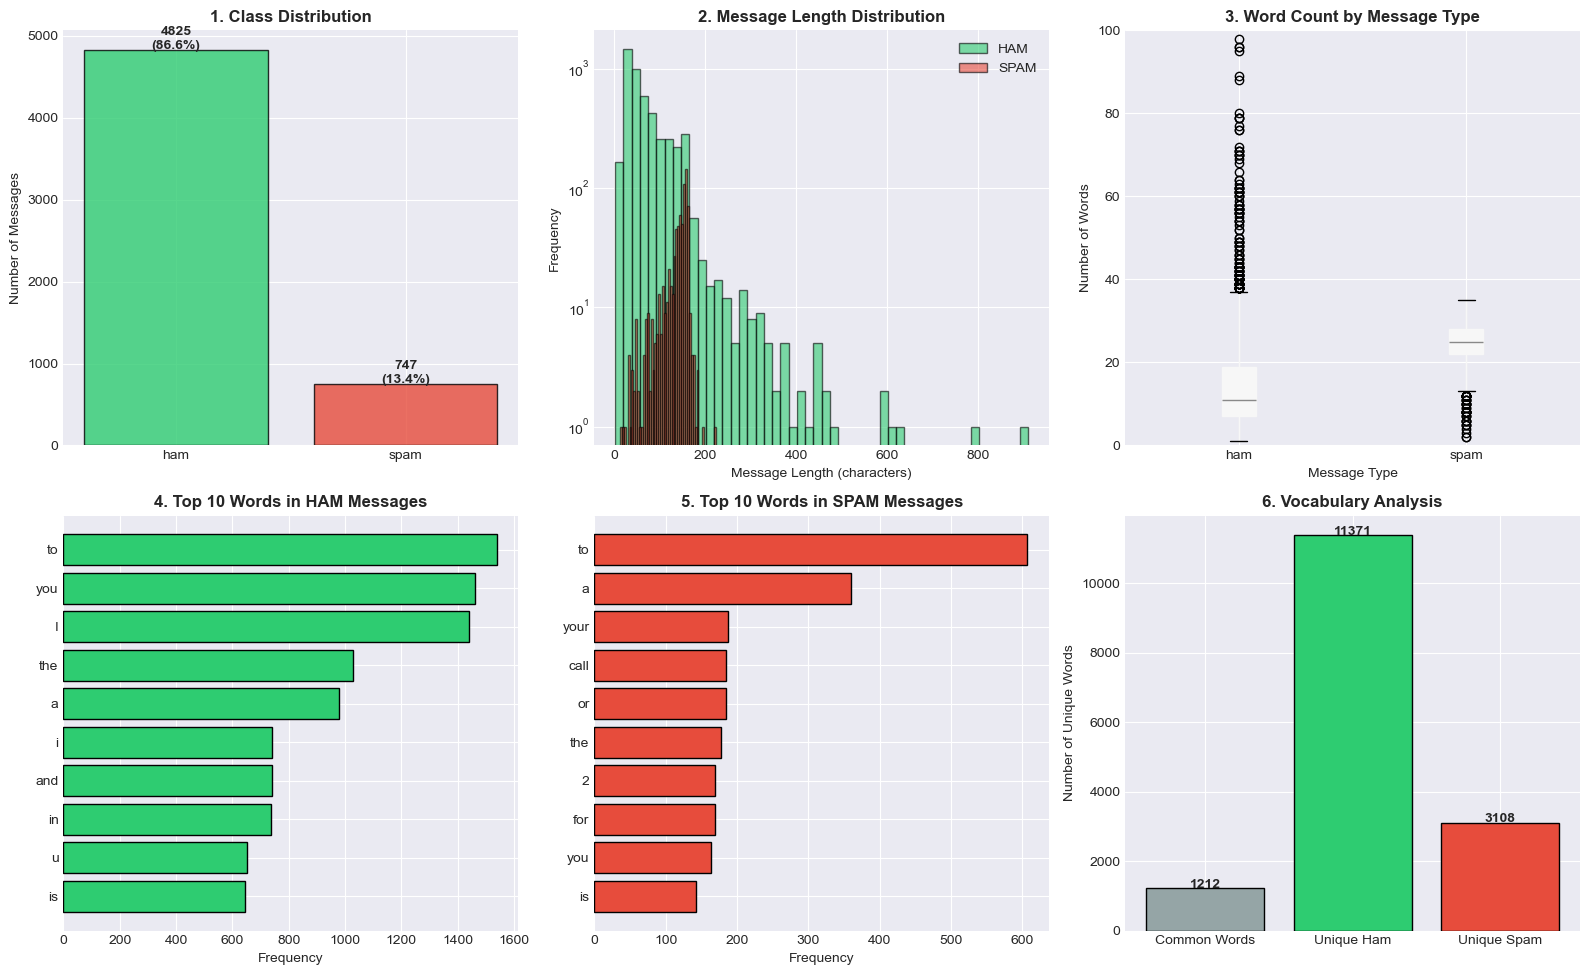

In [4]:
# =============================================
# STEP 2: VISUALIZING SPAM VS HAM PATTERNS
# =============================================
print("STEP 2: VISUALIZING SPAM VS HAM PATTERNS")
print("=" * 45)
from collections import Counter

# Create figure
fig, axes = plt.subplots(2, 3,figsize=(16, 10))
fig.suptitle('SMS/Email Spam Classification - Data Analysis',fontsize=16,fontweight='bold')

# =============================================
# 1. Class Distribution
# =============================================

ax1 = axes[0, 0]
class_counts = df['label'].value_counts()
colors_class = ['#2ecc71', '#e74c3c']
bars = ax1.bar(class_counts.index,class_counts.values,color=colors_class,edgecolor='black',alpha=0.8)
ax1.set_title('1. Class Distribution',fontsize=12,fontweight='bold')
ax1.set_ylabel('Number of Messages')
for bar, count in zip(bars, class_counts.values):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'{count}\n({count/len(df)*100:.1f}%)',
        ha='center',
        fontweight='bold' )

# =============================================
# 2. Message Length Distribution
# =============================================
ax2 = axes[0, 1]
df['message_length'] = df['message'].str.len()
for label, color in zip(['ham', 'spam'],['#2ecc71', '#e74c3c']):
    subset = df[df['label'] == label]['message_length']
    ax2.hist(
        subset,bins=50,alpha=0.6,
        label=label.upper(),
        color=color,edgecolor='black')
ax2.set_title('2. Message Length Distribution',fontsize=12,fontweight='bold')
ax2.set_xlabel('Message Length (characters)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.set_yscale('log')

# =============================================
# 3. Word Count Distribution
# =============================================
ax3 = axes[0, 2]
df['word_count'] = (df['message'].str.split().str.len())
df.boxplot(column='word_count',by='label',ax=ax3,patch_artist=True)
ax3.set_title('3. Word Count by Message Type',fontsize=12,fontweight='bold')
ax3.set_xlabel('Message Type')
ax3.set_ylabel('Number of Words')
ax3.set_ylim(0, 100)
plt.suptitle("")

# =============================================
# 4. Top Words in HAM Messages
# =============================================
ax4 = axes[1, 0]
ham_words = (' '.join(df[df['label']=='ham']['message']).split())
ham_top10 = Counter(ham_words).most_common(10)
words_ham, counts_ham = zip(*ham_top10)
ax4.barh(words_ham,counts_ham,color='#2ecc71',edgecolor='black')
ax4.set_title('4. Top 10 Words in HAM Messages',fontsize=12,fontweight='bold')
ax4.set_xlabel('Frequency')
ax4.invert_yaxis()

# =============================================
# 5. Top Words in SPAM Messages
# =============================================

ax5 = axes[1, 1]
spam_words = (' '.join(df[df['label']=='spam']['message']).split())
spam_top10 = Counter(spam_words).most_common(10)
words_spam, counts_spam = zip(*spam_top10)
ax5.barh(words_spam,counts_spam,color='#e74c3c',edgecolor='black')
ax5.set_title('5. Top 10 Words in SPAM Messages',fontsize=12,fontweight='bold')
ax5.set_xlabel('Frequency')
ax5.invert_yaxis()

# =============================================
# 6. Vocabulary Analysis
# =============================================
ax6 = axes[1, 2]
ham_set = set(' '.join(df[df['label']=='ham']['message']).split())
spam_set = set(' '.join(df[df['label']=='spam']['message']).split())
common_words = len(
ham_set.intersection(spam_set))
unique_ham = len(ham_set - spam_set)
unique_spam = len(spam_set - ham_set)
x_labels = ['Common Words','Unique Ham','Unique Spam']
y_values = [common_words,unique_ham,unique_spam]
bars = ax6.bar(x_labels,y_values,color=['#95a5a6','#2ecc71','#e74c3c'],edgecolor='black')
ax6.set_title('6. Vocabulary Analysis',fontsize=12,fontweight='bold')
ax6.set_ylabel('Number of Unique Words')
for bar, value in zip(bars, y_values):
    ax6.text(
        bar.get_x()+bar.get_width()/2,
        value+20,
        str(value),
        ha='center',
        fontweight='bold'
    )



# Final display

plt.tight_layout()

plt.show()